In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv('/content/drive/MyDrive/dataset.csv')

# =========================================================
# FEATURES
# =========================================================

FEATURES = [
    'avg_pkt_size',
    'std_dev',
    'max_pkt_size',
    'min_pkt_size',
    'pkt_count',
    'avg_iat',
    'iat_std',
    'duration',
    'pkt_rate',
    'size_iqr',
    'burstiness'
]


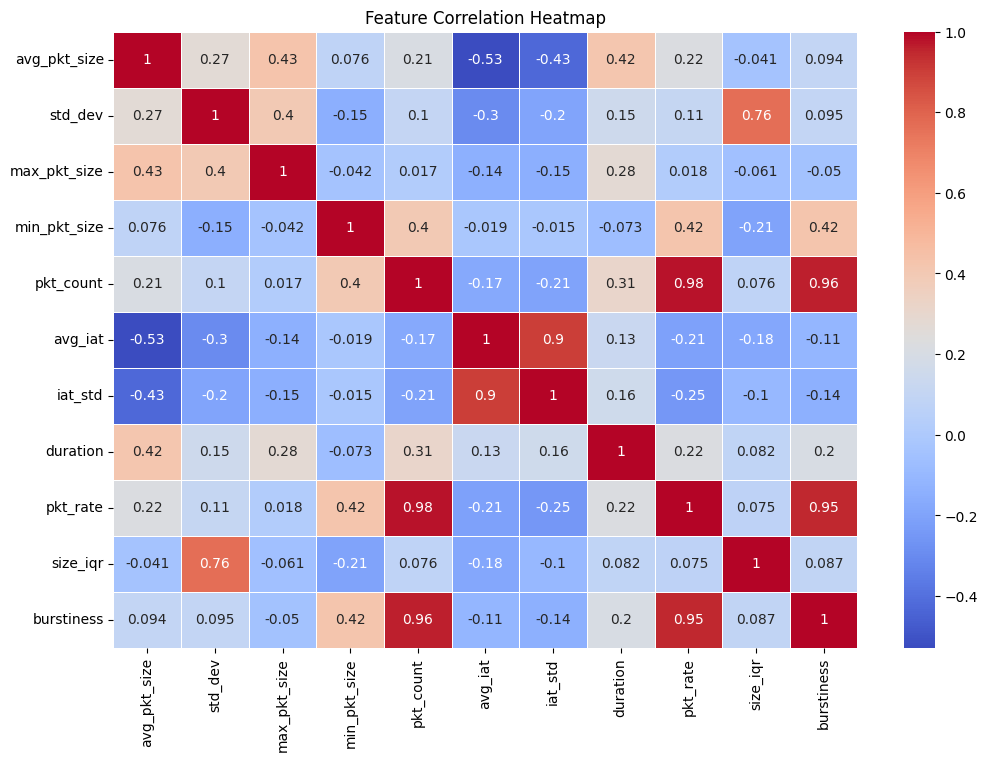

In [ ]:

# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(12,8))

correlation = df[FEATURES].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap')

plt.show()


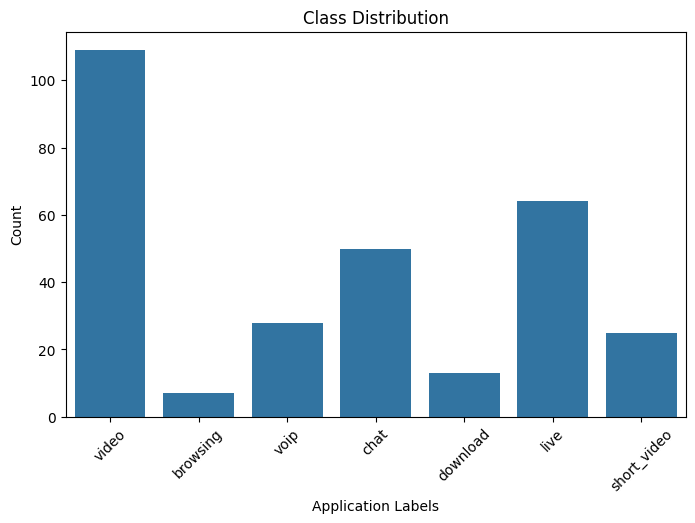

In [ ]:

# =========================================================
# CLASS DISTRIBUTION PLOT
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='label',
    data=df
)

plt.title('Class Distribution')

plt.xlabel('Application Labels')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()


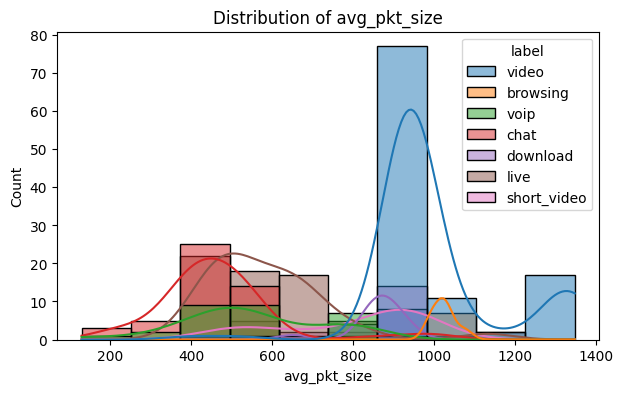

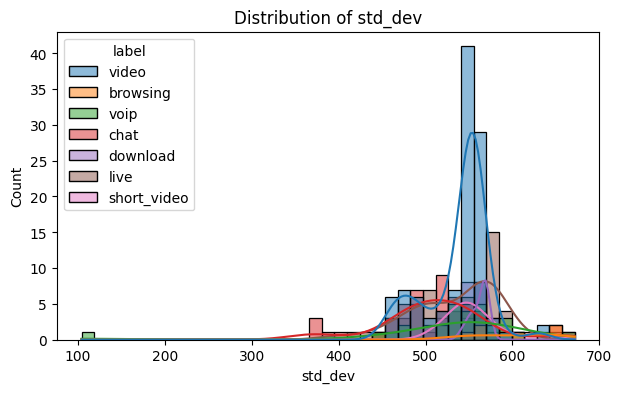

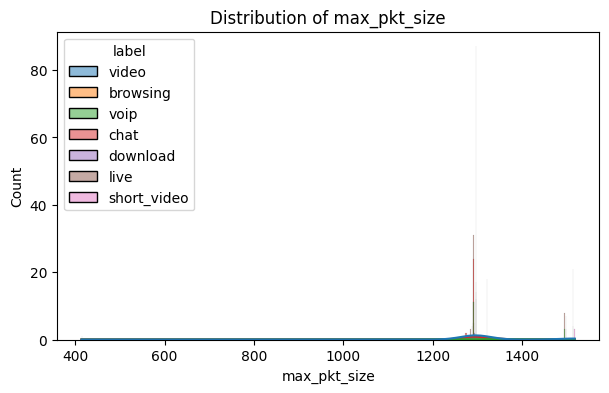

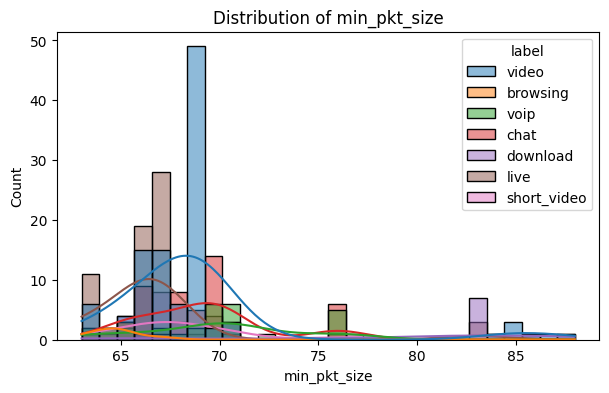

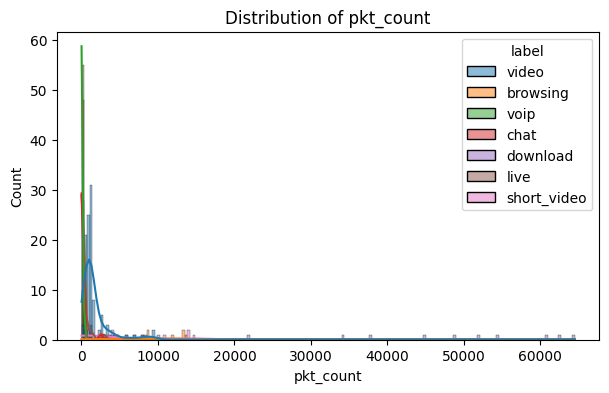

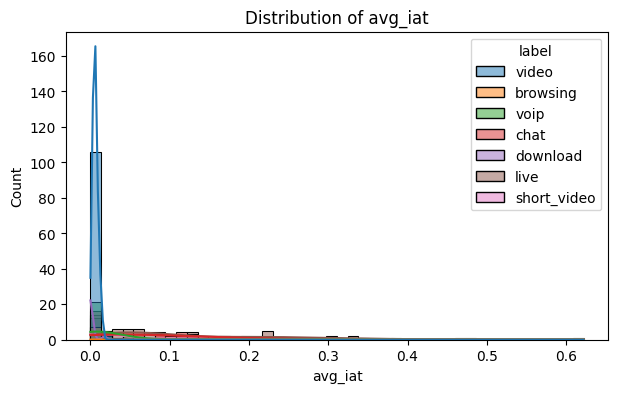

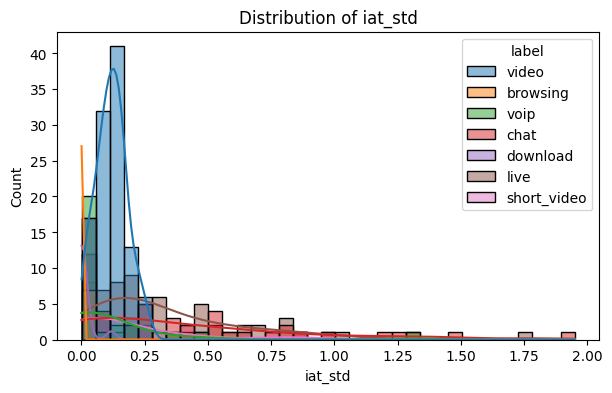

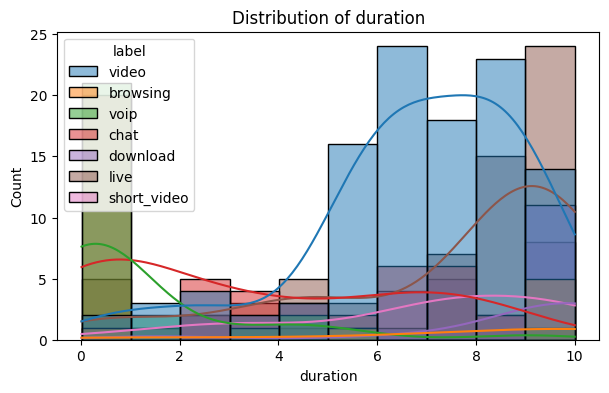

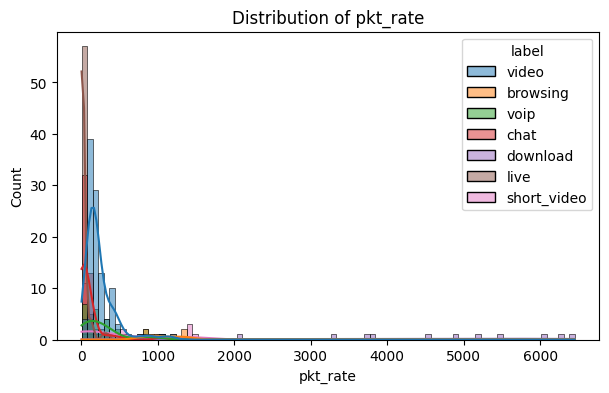

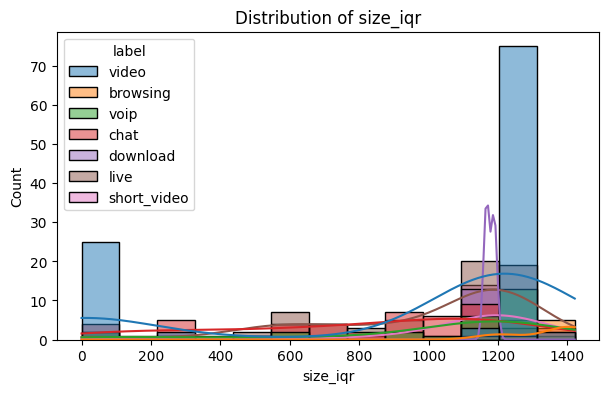

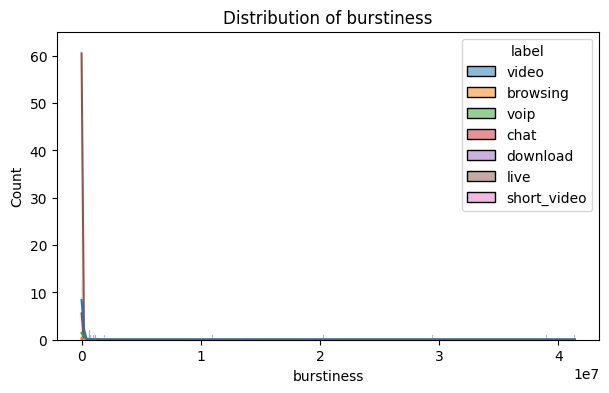

In [ ]:

# =========================================================
# FEATURE DISTRIBUTION PLOTS
# =========================================================

for feature in FEATURES:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=feature,
        hue='label',
        kde=True
    )

    plt.title(f'Distribution of {feature}')

    plt.xlabel(feature)
    plt.ylabel('Count')

    plt.show()

In [ ]:
import pandas as pd
import joblib

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 🔷 Load new dataset
df = pd.read_csv("/content/drive/MyDrive/dataset.csv")

# 🔷 Features (must match training)
X = df[['avg_pkt_size','std_dev','max_pkt_size','min_pkt_size',
        'pkt_count','avg_iat','iat_std','duration',
        'pkt_rate','size_iqr','burstiness']]

# 🔷 Load label encoder
le = joblib.load("/content/drive/MyDrive/label_encoder.pkl")

# 🔷 True labels
y_true = le.transform(df['label'])
rf = joblib.load("/content/drive/MyDrive/QUIC_RF.pkl")
pred_rf = rf.predict(X)

print("\n🔷 RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_true, pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, pred_rf))
print("\nClassification Report:\n",
      classification_report(y_true, pred_rf, zero_division=0))



🔷 RANDOM FOREST RESULTS
Accuracy: 0.9831081081081081

Confusion Matrix:
 [[  7   0   0   0   0   0   0]
 [  0  48   0   0   0   1   1]
 [  0   0  13   0   0   0   0]
 [  0   1   0  63   0   0   0]
 [  0   0   0   0  25   0   0]
 [  0   0   0   0   0 109   0]
 [  0   1   0   0   1   0  26]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       0.96      0.96      0.96        50
           2       1.00      1.00      1.00        13
           3       1.00      0.98      0.99        64
           4       0.96      1.00      0.98        25
           5       0.99      1.00      1.00       109
           6       0.96      0.93      0.95        28

    accuracy                           0.98       296
   macro avg       0.98      0.98      0.98       296
weighted avg       0.98      0.98      0.98       296

